# Cohen MWU p-value calibration — all cell types

Checks that MWU p-values are well-calibrated under the null hypothesis.

All synthetic CREs are assigned the **same activity as the reference** (minP),
so every comparison is truly null. Under correct calibration, p-values should
be Uniform(0,1).

Cohen is **episomal**: all CREs are transfected into all cell types (no integrating
bottleneck), so we run one unified simulation with all cell types included.

Steps:
1. Draw `n_cres` synthetic CREs all at `minP` (null ground truth), replicated across all cell types
2. Simulate 20 library reps × 5 sim reps using empirical Cohen bounds
3. Run MWU for all CREs vs. reference
4. Plot p-value histograms, QQ plots, and empirical FPR at α=0.05 per cell type

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
import math

In [2]:
data_root = Path("/gpfs/gibbs/pi/reilly/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

In [3]:
cluster = SLURMCluster(
    cores=1,
    memory="64G",
    processes=1,
    job_extra_directives=[
        "-p ycga",
        "--job-name=simclust_worker",
        "--time=6:00:00",
        "--output=worker_%j.out"
    ]
)
cluster.scale(jobs=12)
client = Client(cluster)
print(client.dashboard_link, flush=True)

http://10.178.138.40:8787/status


In [4]:
# Confirm n_cres is uniform across cell types (episomal check)
cohen_data = pd.read_parquet(
    data_root / "cohen_ortho" / "retina_single_counting_u6.scmpra",
    columns=["cell_type", "cre_id"]
)
n_cres_by_ct = cohen_data.groupby("cell_type")["cre_id"].nunique()
print("n_cres per cell type (should be uniform):")
print(n_cres_by_ct)
assert n_cres_by_ct.nunique() == 1, "n_cres not uniform — episomal assumption violated!"

n_cres = int(n_cres_by_ct.iloc[0])
cell_types = list(scm.COHEN_BOUNDS.cells_per_cell_type.index)
print(f"\nn_cres={n_cres}, cell_types={cell_types}")
del cohen_data

n_cres per cell type (should be uniform):
cell_type
Bipolar         115
Interneuron     115
Mueller Glia    115
Rod             115
Name: cre_id, dtype: int64

n_cres=115, cell_types=['Bipolar', 'Interneuron', 'Mueller Glia', 'reference']


In [5]:
sim_date       = "2026-03-23"
n_library_reps = 20
n_sims         = 5
minP           = scm.COHEN_BOUNDS.reference_activity
print(f"minP={minP:.6f}, n_library_reps={n_library_reps}, n_sims={n_sims}")

minP=1.201954, n_library_reps=20, n_sims=5


In [6]:
# Cohen is episomal: same CREs transfected into all cell types.
# Batch processing with resume logic (same pattern as power notebook).

def _process_batch(batch, hs_all_ct):
    """Block until batch is computed, run MWU, save, return paths."""
    for s in batch:
        s.save()

    if hs_all_ct is None:
        example_data = scm.scMPRA_data.from_parquet(batch[0].scmpradatp / "0.scmpra")
        hs_all_ct = scm.make_all_by_celltype_hypotheses(
            counts=example_data, reference_cre="reference"
        )

    for s in batch:
        s.add_hypothesis_set("hs_all_ct", hs_all_ct)
        s.mwu("hs_all_ct")
    for s in batch:
        s.save()

    return hs_all_ct, [(s.location, s.name) for s in batch]


batch_size = 10
hs_all_ct = None
batch = []

# --- Resume: collect already-completed sims from disk ---
sim_dir = data_root / f"{sim_date}_cohen_cal"
sim_paths = []
if sim_dir.exists():
    for d in sorted(sim_dir.iterdir()):
        mwu_dir = d / "tests" / "hs_all_ct" / "mwu"
        if mwu_dir.exists() and any(mwu_dir.iterdir()):
            sim_paths.append((sim_dir, d.name))
print(f"Resuming: found {len(sim_paths)} already-complete sims on disk.")

n_remaining = n_library_reps - len(sim_paths)
print(f"Will run {n_remaining} fresh sims to reach {n_library_reps} total.")

for i in range(n_remaining):
    # ALL CREs at minP — null ground truth
    names = [f"synthcre_{j}" for j in range(n_cres - 1)] + ["reference"]
    cre_gt = np.full(n_cres, minP)

    gt_df = pd.concat([
        pd.DataFrame({"cre_id": names, "mu": cre_gt, "cell_type": ct})
        for ct in cell_types
    ], ignore_index=True)

    libraries = [
        scm.simulate_library(CREs=pd.Series(names), library_model=scm.COHEN_BOUNDS.library_model)
        for _ in range(n_sims)
    ]

    sim = scm.de_novo_simulation(
        location=data_root / f"{sim_date}_cohen_cal",
        name=f"sim_{uuid.uuid4().hex[:8]}",
        client=client,
        libraries=libraries,
        library_mapping="corresponding",
        flatten_overtransfection=True,
        n_sims=n_sims,
        experiment_bounds=scm.COHEN_BOUNDS,
        ground_truth=gt_df,
    )
    sim.gamut()
    batch.append(sim)

    if len(batch) == batch_size:
        hs_all_ct, paths = _process_batch(batch, hs_all_ct)
        sim_paths.extend(paths)
        batch = []
        print(f"Batch done — {len(sim_paths)}/{n_library_reps} complete.", flush=True)

if batch:
    hs_all_ct, paths = _process_batch(batch, hs_all_ct)
    sim_paths.extend(paths)
    print(f"Batch done — {len(sim_paths)}/{n_library_reps} complete.", flush=True)

print(f"All {len(sim_paths)} sims done and tested.", flush=True)

Resuming: found 0 already-complete sims on disk.
Will run 20 fresh sims to reach 20 total.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_f9053af0'. Initalizing new object.


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 99.34 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 87.57 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 130.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


...

/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 99.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 104.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 105.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Batch done — 20/20 complete.


All 20 sims done and tested.


In [7]:
# Reload sim handles from disk — objects were discarded after each batch.
sims = [
    scm.de_novo_simulation(location=loc, name=name, client=client)
    for loc, name in sim_paths
]

# Collect raw p-values per cell type
def collect_pvalues_by_ct(sims, hypothesis_set_name, test_type):
    rows = []
    for sim in sims:
        for i in range(sim.get_state_field("n_sims")):
            m = sim._merge_in_ground_truth(
                hypothesis_set_name=hypothesis_set_name,
                test_type=test_type,
                index=i,
            )
            rows.append(m[["comparison_cell_type", "p_value"]])
    combined = pd.concat(rows, ignore_index=True)
    return {
        ct: combined[combined["comparison_cell_type"] == ct]["p_value"].values
        for ct in cell_types
    }

all_pvals = collect_pvalues_by_ct(sims, "hs_all_ct", "mwu")

for ct in cell_types:
    n = len(all_pvals[ct])
    fpr = np.mean(all_pvals[ct] < 0.05)
    print(f"  {ct}: {n} null tests, FPR@0.05 = {fpr:.4f}")

scMPRAforge: INFO: 'state.parquet' found for 'sim_f9053af0', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_435ee6bd', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_90fe2d71', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_38c19085', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_6ad9c14c', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'sim_2c5e3beb', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_27c8bf41', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_ff1f48d1', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_3d8d7720', loading.


  Bipolar: 11400 null tests, FPR@0.05 = 0.0416
  Interneuron: 11400 null tests, FPR@0.05 = 0.0446
  Mueller Glia: 11400 null tests, FPR@0.05 = 0.0282
  reference: 11400 null tests, FPR@0.05 = 0.0560


Saved: output/calibration_mwu_all_cell_types.svg


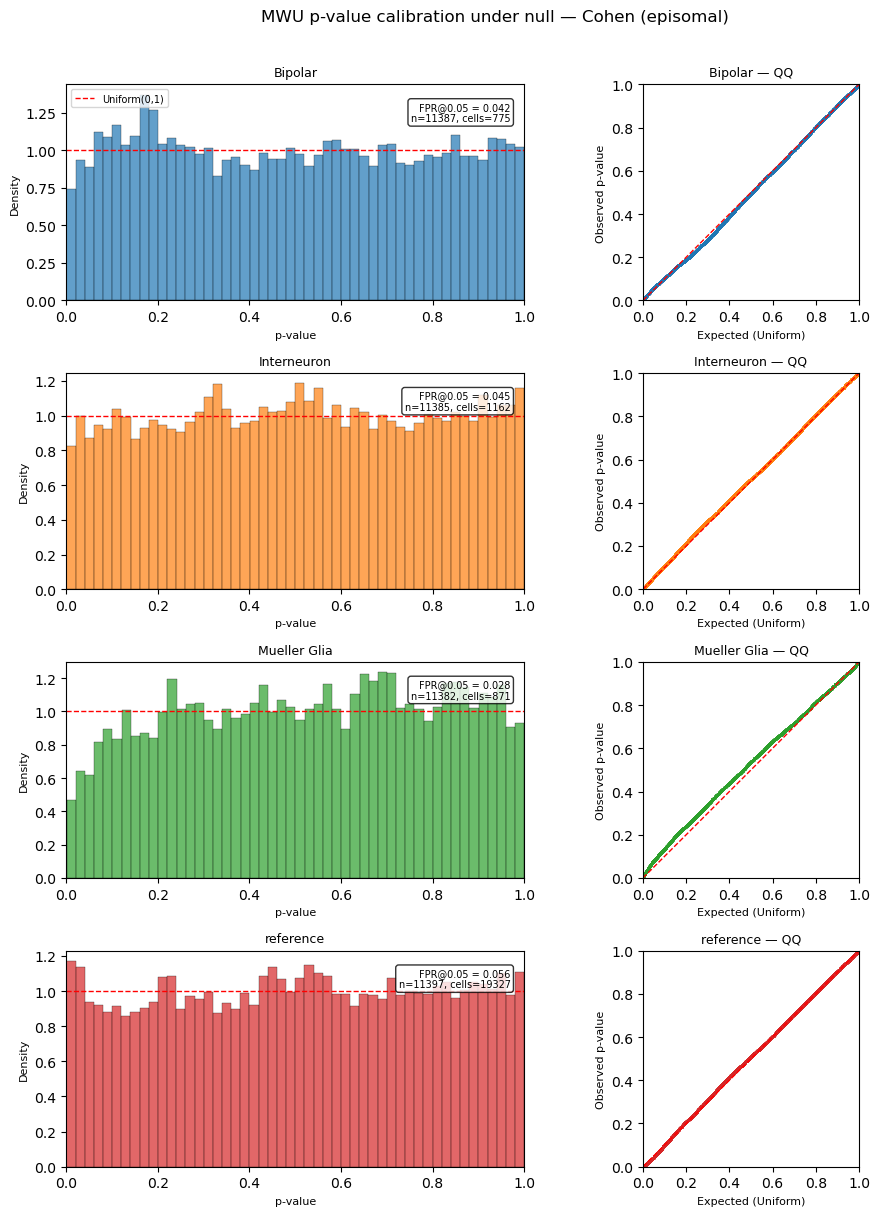

In [8]:
# --- Calibration plots: histograms + QQ, one row per cell type ---
from scipy.stats import uniform

ncols = 2  # histogram | QQ
nrows = len(cell_types)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

palette = sns.color_palette("tab10", n_colors=len(cell_types))

for i, ct in enumerate(cell_types):
    pvals = all_pvals[ct]
    pvals = pvals[np.isfinite(pvals)]  # drop NaN if any
    color = palette[i]
    fpr = np.mean(pvals < 0.05)
    cells = scm.COHEN_BOUNDS.cells_per_cell_type.get(ct, "?")

    # --- Histogram ---
    ax_h = axes[i, 0]
    ax_h.hist(pvals, bins=50, density=True, edgecolor="black",
              linewidth=0.3, alpha=0.7, color=color)
    ax_h.axhline(1.0, color="red", linestyle="--", lw=1, label="Uniform(0,1)")
    ax_h.set_title(f"{ct}", fontsize=9)
    ax_h.set_xlabel("p-value", fontsize=8)
    ax_h.set_ylabel("Density", fontsize=8)
    ax_h.set_xlim(0, 1)
    ax_h.text(
        0.97, 0.92,
        f"FPR@0.05 = {fpr:.3f}\nn={len(pvals)}, cells={cells}",
        transform=ax_h.transAxes, ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
    )
    if i == 0:
        ax_h.legend(fontsize=7, loc="upper left")

    # --- QQ plot ---
    ax_q = axes[i, 1]
    observed = np.sort(pvals)
    n = len(observed)
    expected = uniform.ppf(np.linspace(0, 1, n + 2)[1:-1])
    ax_q.scatter(expected, observed, s=1, alpha=0.5, color=color)
    ax_q.plot([0, 1], [0, 1], "r--", lw=1)
    ax_q.set_title(f"{ct} — QQ", fontsize=9)
    ax_q.set_xlabel("Expected (Uniform)", fontsize=8)
    ax_q.set_ylabel("Observed p-value", fontsize=8)
    ax_q.set_xlim(0, 1)
    ax_q.set_ylim(0, 1)
    ax_q.set_aspect("equal")

fig.suptitle("MWU p-value calibration under null — Cohen (episomal)", fontsize=12, y=1.01)
plt.tight_layout()
svg_path = output_dir / "calibration_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

In [9]:
client.close()
cluster.close()